# Step 6 - Analysis (Single + Compare)


**How this notebook is organized**

1. Select a cell/tune and resolve run(s).
2. Output plots (single or compare).
3. Input plots (single or compare).
4. Synapse plots (planned).
5. Extra analysis (tables + special cases).

Analysis logic lives in `modules_local/analysis/analysis.py`, and plotting in `modules_local/analysis/plotting.py`.
See `modules_local/analysis/README.md` for UI notes and defaults.


## 1. Select runs


In [1]:
# --------------------------
# Defaults (manual mode)
# --------------------------
cell_name = "SST"      # SST, SST_0, PV, PN

tunes_dir = "tunes"
model_dir = "seg_tuned_all"

run_single_stem = "latest"
run_compare_a = "latest"
run_compare_b = "previous"  # use "none" to disable comparison
compare_a_path = ""
compare_b_path = ""

output_metrics_std_mode = "std"  # std or sem for output metric spread


In [2]:
# --------------------------
# Defaults (from config)
# --------------------------
import sys
from pathlib import Path
import json

# Lightweight bootstrap for kernels launched outside repo root.
try:
    from modules_local.notebook_helpers import ensure_scp_repo_on_syspath
except ModuleNotFoundError:
    start = Path.cwd().resolve()
    injected = False
    for cand in (start, *start.parents):
        if (cand / "modules_local").is_dir() and (cand / "run_pipeline.py").is_file():
            if str(cand) not in sys.path:
                sys.path.insert(0, str(cand))
            injected = True
            break

    if not injected:
        for base in (start, start.parent):
            try:
                for child in base.iterdir():
                    if child.is_dir() and (child / "modules_local").is_dir() and (child / "run_pipeline.py").is_file():
                        if str(child) not in sys.path:
                            sys.path.insert(0, str(child))
                        injected = True
                        break
                if injected:
                    break
            except Exception:
                pass

    from modules_local.notebook_helpers import ensure_scp_repo_on_syspath

repo_root = ensure_scp_repo_on_syspath()

from modules_local import analysis

_defaults_path = repo_root / "modules_local" / "analysis" / "analysis_defaults.json"
_defaults = json.loads(_defaults_path.read_text())

for _k in ("plot_window", "input_plot_window"):
    if isinstance(_defaults.get(_k), list) and len(_defaults[_k]) == 2:
        _defaults[_k] = (_defaults[_k][0], _defaults[_k][1])

globals().update(_defaults)


/home/hrbncv/miniconda3/envs/BMTK-py311/lib/python3.11/site-packages/allensdk/model/biophys_sim/config.py:38: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename  # @UnresolvedImport
--No graphics will be displayed.


In [3]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

from modules_local import run_sim
from modules_local.analysis import plotting, analysis, analysis_ui

BASE_DIR = repo_root
CELLS_DIR = BASE_DIR / "cells"

# Widgets (optional)
use_widgets = True
try:
    import ipywidgets as widgetsr
    from IPython.display import display
    _HAVE_WIDGETS = True
except Exception:
    _HAVE_WIDGETS = False


In [4]:
# Selection UI
analysis_ui.build_selection_ui(globals())

# (optional) quick selection check
# analysis_ui.get_selection_from_globals(globals())

Textarea(value='external_data/pyrFiringRateAvg.csv@300.0;color=k;linestyle=--', description='Compare paths', l…

Output()

# 1. Single Plot

Saved:
  /home/hrbncv/SCP/cells/SST/tunes/seg_tuned_all/output_data/SST2.2_base/plots/single_plot.svg
  /home/hrbncv/SCP/cells/SST/tunes/seg_tuned_all/output_data/SST2.2_base/plots/single_plot.png


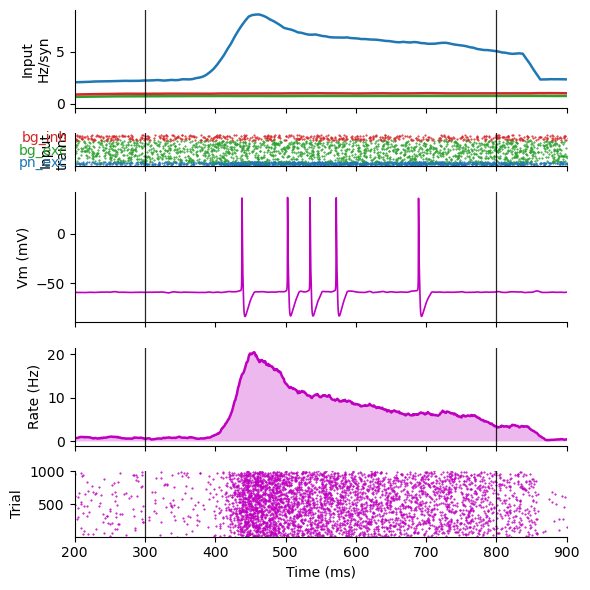

In [5]:
# Manual: paper-ready composite panel (single run)
import json
from modules_local.analysis import paper_panel

sel_paper = analysis_ui.get_selection_from_globals(globals())
run_dir_paper, run_select_warnings = paper_panel.resolve_single_run_for_paper_panel(sel_paper)
res_paper = run_sim.load_results(run_dir_paper)

single_plot_preset_path = repo_root / "modules_local" / "analysis" / "analysis_presets" / "single_plot.json"
single_plot_preset = json.loads(single_plot_preset_path.read_text())

paper_panel_cfg = dict(single_plot_preset.get("defaults", {}))

paper_panel_result = paper_panel.plot_paper_panel_from_results(
    res_paper,
    run_dir=run_dir_paper,
    **paper_panel_cfg,
)

for w in run_select_warnings + paper_panel_result["warnings"]:
    print("Warning:", w)

if paper_panel_result["exported_paths"]:
    print("Saved:")
    for p in paper_panel_result["exported_paths"]:
        
        print("  " + str(p))



## 2. Output plots (standard)


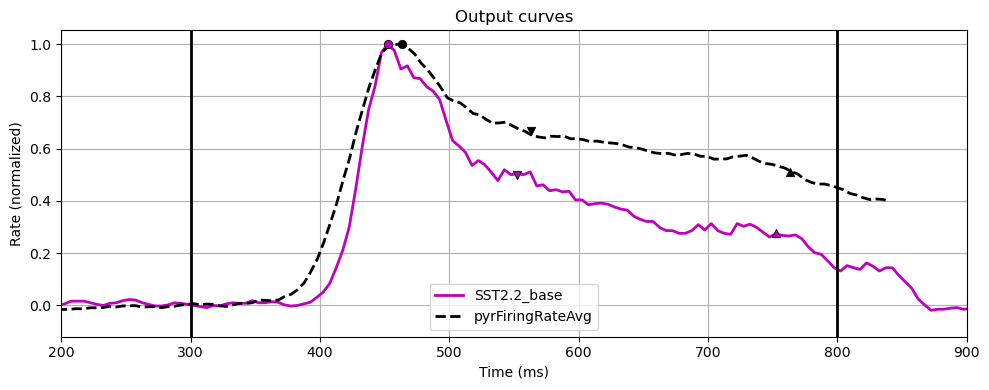

In [6]:
# Outputs UI (single or compare)
analysis_ui.build_outputs_ui(globals())


## 3. Input plots (standard)


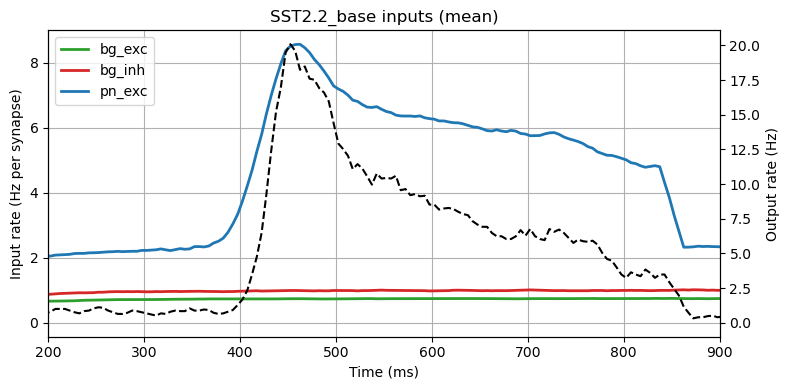

In [7]:
# Inputs UI (single or compare)
analysis_ui.build_inputs_ui(globals())


## 4. Synapse plots (planned)


## 5. Extra analysis (tables + special cases)


In [8]:
# Extra analysis UI
analysis_ui.get_selection_from_globals(globals())
analysis_ui.build_extra_ui(globals())


In [9]:
# # Manual: single-run tables (extra)
# analysis_ui.run_extra_tables_from_globals(globals())


### Output metrics (bio)


In [10]:
metrics = analysis_ui.run_output_metrics_from_globals(globals())
if metrics:
    show_params = bool(globals().get("output_metrics_show_params", True))
    ref_label = globals().get("output_metrics_ref_label")
    show_delta = bool(globals().get("output_metrics_show_delta", False))
    highlight_best = bool(globals().get("output_metrics_highlight_best", False))
    use_plot_keys = bool(globals().get("output_metrics_use_plot_keys_for_tables", True))
    table_metric_keys = list(globals().get("output_metrics_plot_keys") or []) if use_plot_keys else None
    if isinstance(metrics, dict) and all(isinstance(v, dict) for v in metrics.values()):
        analysis_ui.show_md(
            analysis_ui.format_output_metrics_tables_columns(
                metrics,
                title="Output metrics",
                show_params=show_params,
                reference_label=ref_label,
                show_deltas=show_delta,
                highlight_best=highlight_best,
                metric_keys=table_metric_keys,
            )
        )
    else:
        sel = analysis_ui.get_selection_from_globals(globals())
        label = analysis.run_label(analysis.resolve_run(sel["base"], sel["run_single"]))
        analysis_ui.show_md(
            analysis_ui.format_output_metrics_tables(
                metrics,
                title=f"Output metrics ({label})",
                show_params=show_params,
                metric_keys=table_metric_keys,
            )
        )


### Output metrics
| Metric | SST2.2_base | pyrFiringRateAvg |
| --- | --- | --- |
| **baseline_mean** | 0.696 +/- 0.108 (SEM) | 2.25 |
| **peak_rate_hz_raw** | 20.1 +/- 0.764 (SEM) | 6.25 |
| **peak_latency_ms** | 152 +/- 2.02 (SEM) | 3.83 |
| **drop_pct** | 50.2 +/- 1.19 (SEM) | 10.1 |
| **rebound_pct** | 72.2 +/- 0.946 (SEM) | 37 |
| **auc** | 0.175 +/- 0.00208 (SEM) | 0.127 |

### Spike stats (optional)


In [11]:
# # Manual: spike stats (extra)
# analysis_ui.run_spike_stats_from_globals(globals())


### 5.1 Comparison tables + synapse compare plots (optional)


In [12]:
# # Manual: comparison tables + synapse compare plots (extra)
# analysis_ui.run_extra_compare_from_globals(globals())


### 4.2 Snapshot compare tables (optional)


In [13]:
# # Manual: snapshot compare tables (extra)
# analysis_ui.run_snapshot_compare_from_globals(globals())


### 4.3 IClamp analysis (optional)


In [14]:
# # Manual: IClamp analysis (extra)
# analysis_ui.run_iclamp_analysis_from_globals(globals())


## 6. Paper panel figure (manual)


In [15]:
# # Manual: paper-ready composite panel (single run)
# import json
# from modules_local.analysis import paper_panel

# sel_paper = analysis_ui.get_selection_from_globals(globals())
# run_dir_paper, run_select_warnings = paper_panel.resolve_single_run_for_paper_panel(sel_paper)
# res_paper = run_sim.load_results(run_dir_paper)

# single_plot_preset_path = repo_root / "modules_local" / "analysis" / "analysis_presets" / "single_plot.json"
# single_plot_preset = json.loads(single_plot_preset_path.read_text())
# paper_panel_cfg = dict(single_plot_preset.get("defaults", {}))

# paper_panel_result = paper_panel.plot_paper_panel_from_results(
#     res_paper,
#     run_dir=run_dir_paper,
#     **paper_panel_cfg,
# )

# for w in run_select_warnings + paper_panel_result["warnings"]:
#     print("Warning:", w)

# if paper_panel_result["exported_paths"]:
#     print("Saved:")
#     for p in paper_panel_result["exported_paths"]:
#         print("  " + str(p))

